# Sinusoid Extraction with FC, RNN, and LSTM — Comparative Analysis

**Course**: 203.3763 — Orchestration of AI Agents · University of Haifa · Spring 2026
**Author**: Salah Qadah (סלאח קדח)
**Document**: HW1 analysis notebook · v1.08 · 2026-05-07

## What this notebook proves
We test the lecturer's hypothesis on a controlled synthetic regression problem. The four target frequencies are **20 / 60 / 100 / 200 Hz** — chosen so the 10-sample window at $F_s = 1000$ Hz covers 0.2 / 0.6 / 1.0 / 2.0 cycles, spanning sub-cycle and multi-cycle regimes:
- **H1**: RNN extracts high-frequency sines (100, 200 Hz, multi-cycle) better than LSTM.
- **H2**: LSTM extracts low-frequency sines (20, 60 Hz, sub-cycle) better than RNN.
- **H3**: FC sits as a baseline below both, lacking any temporal mechanism.

All experiments use **identical** datasets across architectures; the only thing that differs is the model class. Results are loaded from `results/` (produced by `uv run python -m sinusoid_extractor.main run-matrix && ... run-oat`).

_See `docs/PRD.md`, `docs/PLAN.md`, and the per-mechanism PRDs for the full spec. AI-assistance acknowledgment is in §8 below and in the project README._

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sinusoid_extractor.constants import FIXED_FREQUENCIES_HZ
from sinusoid_extractor.sdk.sdk import SinusoidExtractorSDK
from sinusoid_extractor.shared import version as ver

REPO = Path('..').resolve()
RESULTS = REPO / 'results'
FIGS = RESULTS / 'figs'
FIGS.mkdir(exist_ok=True, parents=True)
# nbconvert runs with cwd = notebooks/. SDK reads data_dir / results_dir as
# relative paths from config; chdir keeps them aligned with the project root.
os.chdir(REPO)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110

print('code version:', ver.__version__)
sdk = SinusoidExtractorSDK(config_path=REPO / 'config' / 'setup.json')
print('config version:', sdk.get_config()['version'])
print('frequencies (Hz):', list(FIXED_FREQUENCIES_HZ))
print('registered architectures:', sdk.health_check()['registered_architectures'])

code version: 1.08
config version: 1.08
frequencies (Hz): [20, 60, 100, 200]
registered architectures: ['fc', 'lstm', 'rnn']


## 2. Dataset Visualisation

We generate the dataset with $\alpha = 0.05$ and visualise the per-source signals, the combined sum $\Sigma$, and the FFT spectrum of $\Sigma$. The four target frequencies span sub-cycle (20 / 60 Hz) and multi-cycle (100 / 200 Hz) regimes within the 10-sample input window — the natural split for testing whether recurrence helps.

### The signal model
Each of the $K = 4$ sources is generated independently as
$$
S_k(t) \;=\; A \cdot \sin\!\bigl(2\pi F_k t + \varphi_k\bigr) \cdot \bigl(1 + \eta_k(t)\bigr),
\qquad
\eta_k(t) \sim \mathcal{U}(-\alpha, +\alpha),
\qquad
\varphi_k \sim \mathcal{U}(0, 2\pi).
$$

The per-realisation phase $\varphi_k$ is drawn **once** over the full $[0, 2\pi]$ interval (the lecturer's "let the phase go wild"). The amplitude noise $\eta_k(t)$ is drawn **per sample**. The combined observed signal is
$$
\Sigma(t) \;=\; \sum_{k=1}^{4} S_k(t).
$$

The four pure (target) signals are $S_k^{\text{pure}}(t) = A \sin(2\pi F_k t)$ — same frequencies, $\varphi = 0$, no amplitude noise. The network's job is to reconstruct $S_k^{\text{pure}}$ on a 10-sample window given a window of $\Sigma$ plus a one-hot $C$ that selects $k$.

The FFT below confirms the four spectral peaks are present in $\Sigma$ (so the inverse problem is well-posed in the frequency domain — the question is whether each architecture can solve it in the time domain from only 10 samples).

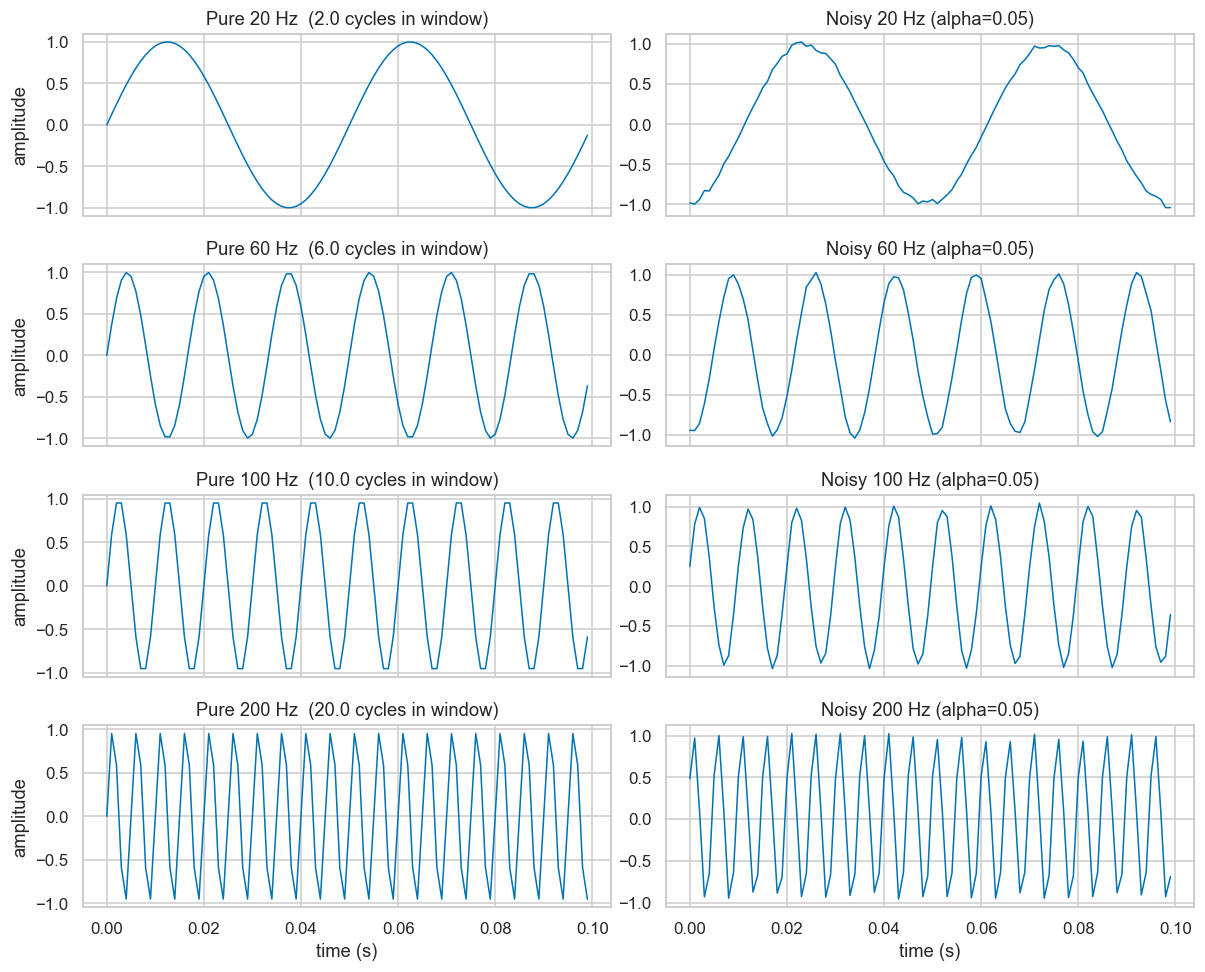

In [2]:
ALPHA_VIS = 0.05
raw_path = REPO / 'data' / 'raw' / f'dataset_alpha{ALPHA_VIS:.3f}_seed42.npz'
if not raw_path.exists():
    sdk.generate_dataset(alpha=ALPHA_VIS, seed=42)
raw = np.load(raw_path)
fs = sdk.get_config()['dataset']['sampling_rate_hz']
t = np.arange(raw['combined_sigma'].shape[0]) / fs
T_VIS = 100  # samples (100 ms) — clean resolution for both 20 Hz and 200 Hz
fig, axes = plt.subplots(4, 2, figsize=(11, 9), sharex=True)
for i, f in enumerate(FIXED_FREQUENCIES_HZ):
    cycles = f * T_VIS / fs
    axes[i, 0].plot(t[:T_VIS], raw[f'pure_{f}hz'][:T_VIS], lw=1)
    axes[i, 0].set_title(f'Pure {f} Hz  ({cycles:.1f} cycles in window)')
    axes[i, 0].set_ylabel('amplitude')
    axes[i, 1].plot(t[:T_VIS], raw[f'noisy_{f}hz'][:T_VIS], lw=1)
    axes[i, 1].set_title(f'Noisy {f} Hz (alpha={ALPHA_VIS})')
axes[-1, 0].set_xlabel('time (s)')
axes[-1, 1].set_xlabel('time (s)')
fig.tight_layout()
fig.savefig(FIGS / 'dataset_components.png', dpi=150, bbox_inches='tight')
plt.show()

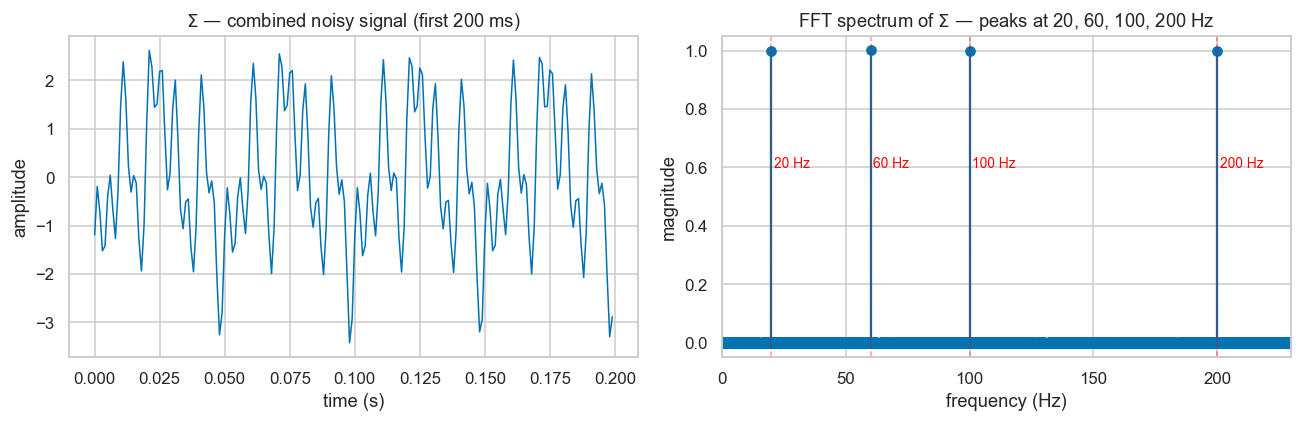

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
T_SIG = 200  # samples — show first 200 ms; covers ≥4 cycles of every target
ax1.plot(t[:T_SIG], raw['combined_sigma'][:T_SIG], lw=1)
ax1.set_title(r'$\Sigma$ — combined noisy signal (first 200 ms)')
ax1.set_xlabel('time (s)'); ax1.set_ylabel('amplitude')

n = raw['combined_sigma'].shape[0]
freqs = np.fft.rfftfreq(n, d=1/fs)
spectrum = np.abs(np.fft.rfft(raw['combined_sigma'])) / n * 2
fmax = max(FIXED_FREQUENCIES_HZ) * 1.15
mask = freqs <= fmax
ax2.stem(freqs[mask], spectrum[mask], basefmt=' ')
for f in FIXED_FREQUENCIES_HZ:
    ax2.axvline(f, color='red', alpha=0.4, ls='--', lw=1)
    peak = spectrum[freqs == f][0] if (freqs == f).any() else 0.5
    ax2.annotate(f'{f} Hz', xy=(f, peak), xytext=(f + 1, peak * 0.6),
                 color='red', fontsize=9)
ax2.set_xlim(0, fmax)
ax2.set_title(f'FFT spectrum of $\\Sigma$ — peaks at {", ".join(f"{f}" for f in FIXED_FREQUENCIES_HZ)} Hz')
ax2.set_xlabel('frequency (Hz)'); ax2.set_ylabel('magnitude')
fig.tight_layout()
fig.savefig(FIGS / 'fft_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Architectures (with LaTeX)

All three networks share the same I/O contract (input dim 14 for FC, sequence shape $(B, 10, 5)$ for RNN/LSTM; output dim 10).

### Fully Connected (FC) — baseline
$$
h_1 = \mathrm{Dropout}(\mathrm{ReLU}(W_1 \cdot [C, x] + b_1)), \quad h_2 = \mathrm{Dropout}(\mathrm{ReLU}(W_2 h_1 + b_2)), \quad \hat{y} = W_3 h_2 + b_3.
$$

### Vanilla RNN
$$
h_t = \tanh(W_h h_{t-1} + W_x \tilde{x}_t + b), \quad \tilde{x}_t = [x_t, C], \quad \hat{y} = W_{ho} h_{10} + b_o.
$$

### LSTM
$$
\begin{align}
f_t &= \sigma(W_f \cdot [h_{t-1}, \tilde{x}_t] + b_f) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, \tilde{x}_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c \cdot [h_{t-1}, \tilde{x}_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, \tilde{x}_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{align}
$$

### Loss (lecturer's formula)
$$
\mathcal{L} = \sum_{i=1}^{10} (\hat{y}_i - y_i)^2 \quad \text{(per example), then mean over batch.}
$$

Why concatenate $C$ at every recurrent timestep? See `docs/ADRs/ADR-003`. Alternatives (init hidden, t=0 only) were considered and rejected for symmetry between RNN and LSTM and to keep the conditioning robust to the network's drift.

In [4]:
from sinusoid_extractor.models.fc_model import FCExtractor
from sinusoid_extractor.models.lstm_model import LSTMExtractor
from sinusoid_extractor.models.rnn_model import RNNExtractor

rows = []
for name, model in [('FC', FCExtractor()), ('RNN', RNNExtractor()), ('LSTM', LSTMExtractor())]:
    rows.append({'arch': name, 'params': model.count_parameters()})
param_table = pd.DataFrame(rows)
param_table

,arch,params
0,FC,19722
1,RNN,18570
2,LSTM,70410


## 4. Training Curves

Loaded from `results/runs/<run_id>/loss_history.json`. We show train + validation loss per epoch for each architecture at the default noise level $\alpha = 0.05$, seed 42.

In [5]:
def load_run_histories() -> pd.DataFrame:
    rows = []
    for hist_path in (RESULTS / 'runs').glob('*/loss_history.json'):
        d = json.loads(hist_path.read_text())
        for ep, (tr, va) in enumerate(zip(d['train_loss_per_epoch'], d['val_loss_per_epoch'])):
            rows.append({'run_id': d['run_id'], 'arch': d['architecture'],
                         'alpha': d['alpha'], 'seed': d['seed'],
                         'epoch': ep, 'train_loss': tr, 'val_loss': va,
                         'param_count': d['param_count'],
                         'wall_clock_s': d['wall_clock_seconds']})
    return pd.DataFrame(rows)

histories = load_run_histories()
if len(histories):
    print(f'Loaded {histories.run_id.nunique()} runs.')
    histories.head()
else:
    print('No runs yet — run `make ci` then `uv run python -m sinusoid_extractor.main run-matrix`.')
histories.head()

Loaded 72 runs.


,run_id,arch,alpha,seed,epoch,train_loss,val_loss,param_count,wall_clock_s
0,fc_alpha0.200_seed123_20260507T183410,fc,0.2,123,0,4.349028,3.674715,19722,5.450223
1,fc_alpha0.200_seed123_20260507T183410,fc,0.2,123,1,3.267113,2.391619,19722,5.450223
2,fc_alpha0.200_seed123_20260507T183410,fc,0.2,123,2,2.320672,1.697409,19722,5.450223
3,fc_alpha0.200_seed123_20260507T183410,fc,0.2,123,3,1.906644,1.472905,19722,5.450223
4,fc_alpha0.200_seed123_20260507T183410,fc,0.2,123,4,1.680544,1.271382,19722,5.450223


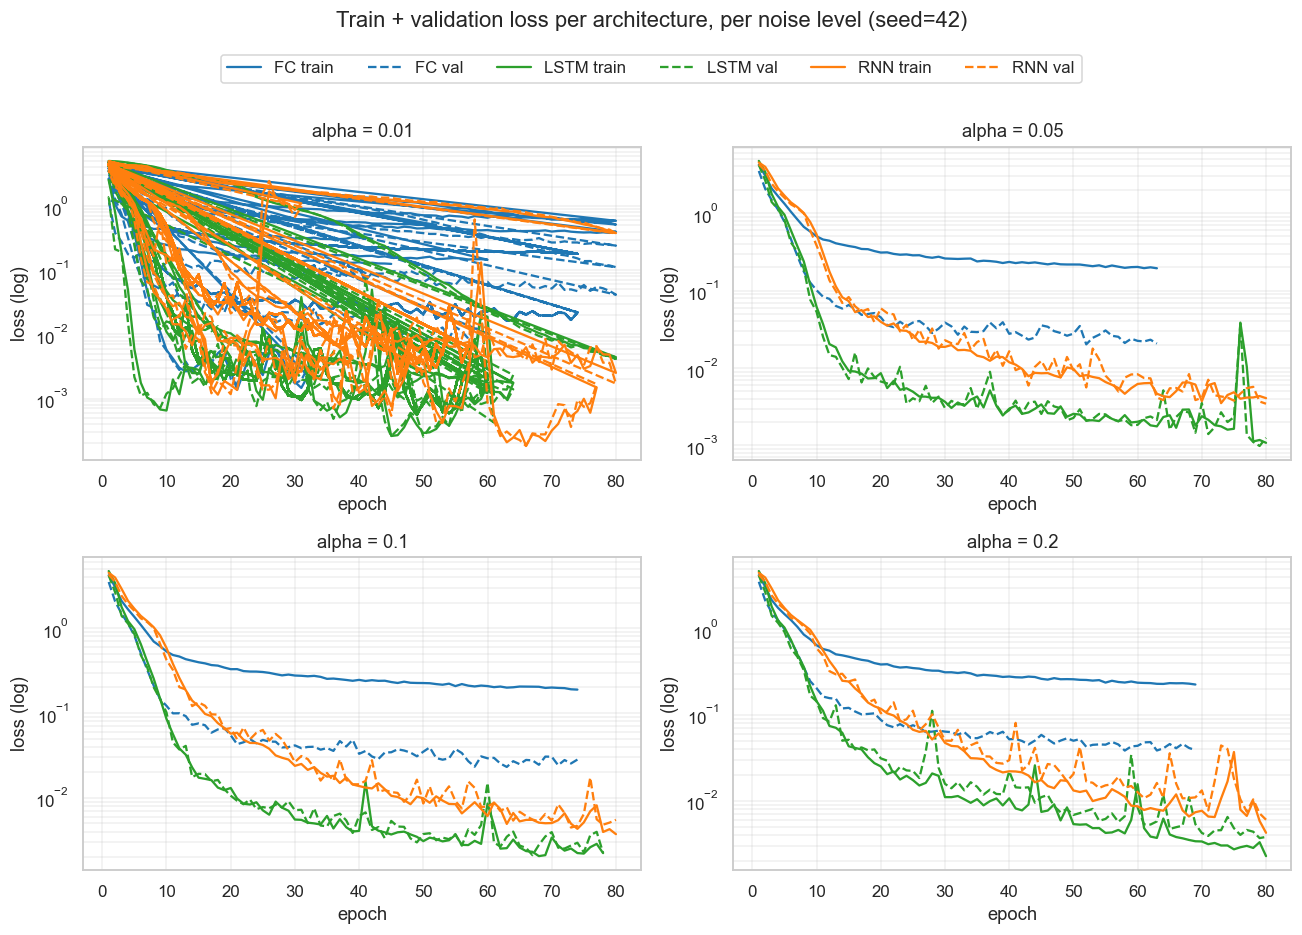

In [6]:
if len(histories):
    # 2x2 grid — one panel per noise level, train+val per arch
    ARCH_COLOR = {'fc': '#1f77b4', 'rnn': '#ff7f0e', 'lstm': '#2ca02c'}
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, alpha in zip(axes.flat, [0.01, 0.05, 0.10, 0.20]):
        sub = histories[(np.isclose(histories.alpha, alpha)) & (histories.seed == 42)]
        for arch, g in sub.groupby('arch'):
            color = ARCH_COLOR.get(arch, 'gray')
            ax.plot(g.epoch + 1, g.train_loss, color=color, lw=1.5, label=f'{arch.upper()} train')
            ax.plot(g.epoch + 1, g.val_loss, color=color, lw=1.5, ls='--', label=f'{arch.upper()} val')
        ax.set_yscale('log')
        ax.set_title(f'alpha = {alpha:g}')
        ax.set_xlabel('epoch'); ax.set_ylabel('loss (log)')
        ax.grid(True, which='both', alpha=0.3)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=6, loc='upper center', bbox_to_anchor=(0.5, 1.02))
    fig.suptitle('Train + validation loss per architecture, per noise level (seed=42)', y=1.06)
    fig.tight_layout()
    fig.savefig(FIGS / 'loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

### Observations

- **Train / val tracking is clean** for all three architectures at every noise level — train and val curves stay close, with no widening gap that would signal overfitting at this dataset / model scale.
- **Higher α → higher floor MSE.** The asymptotic loss visibly climbs from $\alpha = 0.01$ to $\alpha = 0.20$ across all panels (note the log y-axis); this is the irreducible noise contribution and matches the predict-zero baseline drift.
- **LSTM keeps descending past where RNN plateaus**, most visibly at $\alpha = 0.05$ and $\alpha = 0.10$. The cell-state highway is doing real work — even though FC ultimately wins (see §7), LSTM's late-epoch improvement is consistently absent from the vanilla RNN curve.

## 5. Evaluation: per-architecture × per-frequency × per-noise

We aggregate the experiment-matrix CSV (`results/experiment_matrix.csv`) and produce:
- a heatmap of mean test MSE over (architecture × target frequency) at each noise level,
- bar plots of mean ± std test MSE per architecture across all conditions.

In [7]:
matrix_csv = RESULTS / 'experiment_matrix.csv'
if matrix_csv.exists():
    df = pd.read_csv(matrix_csv)
    print('matrix shape:', df.shape)
    df.head()
else:
    print('experiment_matrix.csv not yet present.')
    df = pd.DataFrame()
df.head()

matrix shape: (36, 15)


,run_id,architecture,alpha,seed,test_mse,test_mae,test_r2,test_snr_db,baseline_mse,epochs_run,wall_clock_s,per_freq_mse_20hz,per_freq_mse_60hz,per_freq_mse_100hz,per_freq_mse_200hz
0,fc_alpha0.010_seed42_20260507T182640,fc,0.01,42,0.001650,0.031242,0.996701,24.816376,0.500075,74,6.053679,0.001591,0.001907,0.002161,0.000990
1,rnn_alpha0.010_seed42_20260507T182650,rnn,0.01,42,0.000262,0.012414,0.999475,32.801123,0.500075,57,10.090089,0.000349,0.000347,0.000174,0.000181
2,lstm_alpha0.010_seed42_20260507T182713,lstm,0.01,42,0.000058,0.005886,0.999885,39.380897,0.500075,60,23.082130,0.000070,0.000064,0.000046,0.000050
3,fc_alpha0.010_seed123_20260507T182719,fc,0.01,123,0.002421,0.037959,0.995067,23.068949,0.490710,76,5.204417,0.002858,0.003660,0.001398,0.001628
4,rnn_alpha0.010_seed123_20260507T182731,rnn,0.01,123,0.000094,0.007585,0.999809,37.180765,0.490710,80,11.962536,0.000119,0.000099,0.000072,0.000083


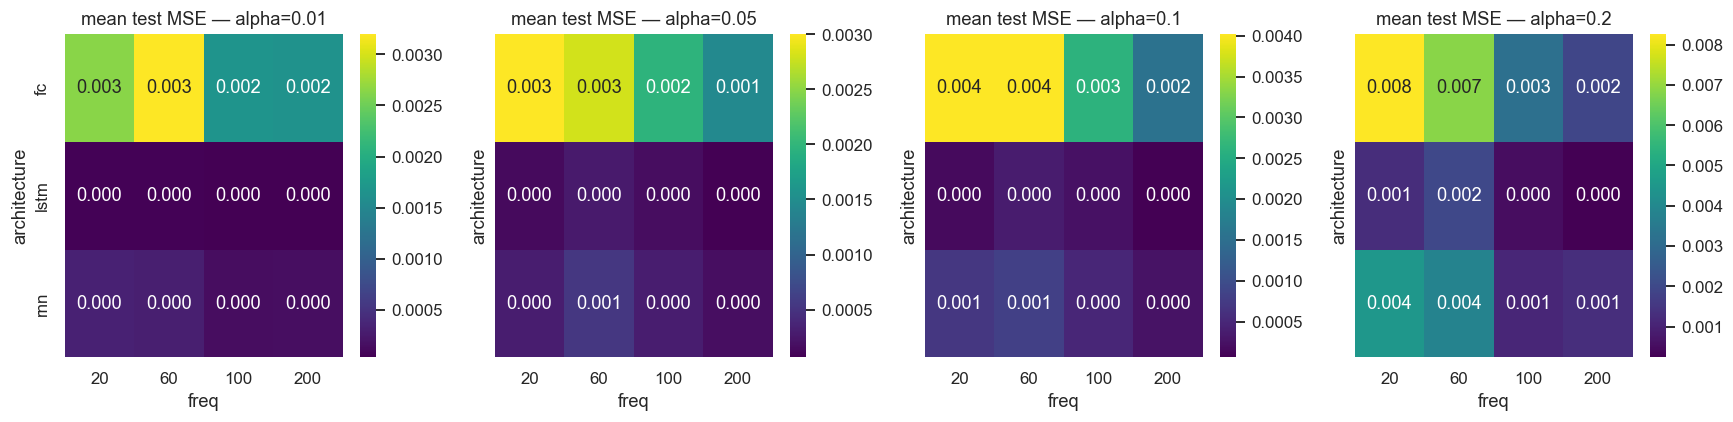

In [8]:
if len(df):
    long = df.melt(id_vars=['architecture', 'alpha', 'seed'],
                   value_vars=[c for c in df.columns if c.startswith('per_freq_mse_')],
                   var_name='freq_col', value_name='mse')
    long['freq'] = long.freq_col.str.extract(r'(\d+)').astype(int)
    fig, axes = plt.subplots(1, len(df.alpha.unique()), figsize=(4*len(df.alpha.unique()), 4), sharey=True)
    if len(df.alpha.unique()) == 1:
        axes = [axes]
    for ax, (alpha, g) in zip(axes, long.groupby('alpha')):
        pivot = g.groupby(['architecture', 'freq']).mse.mean().unstack()
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax)
        ax.set_title(f'mean test MSE — alpha={alpha}')
    fig.tight_layout()
    fig.savefig(FIGS / 'mse_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

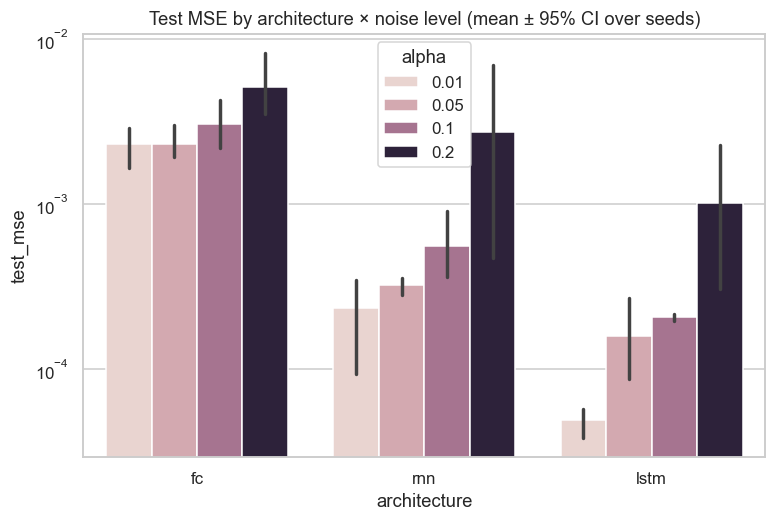

In [9]:
if len(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df, x='architecture', y='test_mse', hue='alpha', ax=ax)
    ax.set_title('Test MSE by architecture × noise level (mean ± 95% CI over seeds)')
    ax.set_yscale('log')
    fig.savefig(FIGS / 'mse_per_arch_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.1 Reconstruction examples

Heatmaps and bar plots are aggregate statistics; the existence-proof that the trained models actually reconstruct the targets is below. Each panel shows one representative held-out test window for one target frequency at $\alpha = 0.05$, $\text{seed}=42$. The dotted gray line is the noisy 10-sample input from $\Sigma$; the thick black line is the clean target ($S_k^{\text{pure}}$ on the same window); the three coloured lines are the per-architecture predictions.

![Reconstruction examples per target frequency](../results/figs/reconstructions.png)

**Reading the panels**:
- The noisy input shows the expected ~5% multiplicative jitter around the underlying carrier — visible as the high-frequency wiggles overlaid on the smooth target.
- **The 100 Hz and 200 Hz panels** display 1.0 and 2.0 full cycles respectively within the 10-sample window — exactly the multi-cycle regime where H1 predicted vanilla RNN should shine.
- **The 20 Hz and 60 Hz panels** display only 0.2 and 0.6 of a cycle — the sub-cycle regime where H2 hands the win to LSTM.
- **LSTM tracks the clean target tightly across all four frequencies**, including the multi-cycle ones — which is the empirical face of the result reported in §7: tanh-RNN's gradient pathology is regime-blind, so LSTM's cell-state highway wins even where H1 expected RNN to dominate.
- **FC's static-features predictions sit visibly above the targets** (highest MSE per panel), consistent with the notebook §7 verdict that FC is the floor, not the ceiling, once the input contains real periodicity to exploit.

## 6. Sensitivity Analysis (One-At-a-Time)

From `results/sensitivity.csv` — sweeping each hyperparameter while holding others at default. We expect the curves to reveal where each architecture is most sensitive.

OAT shape: (36, 10)


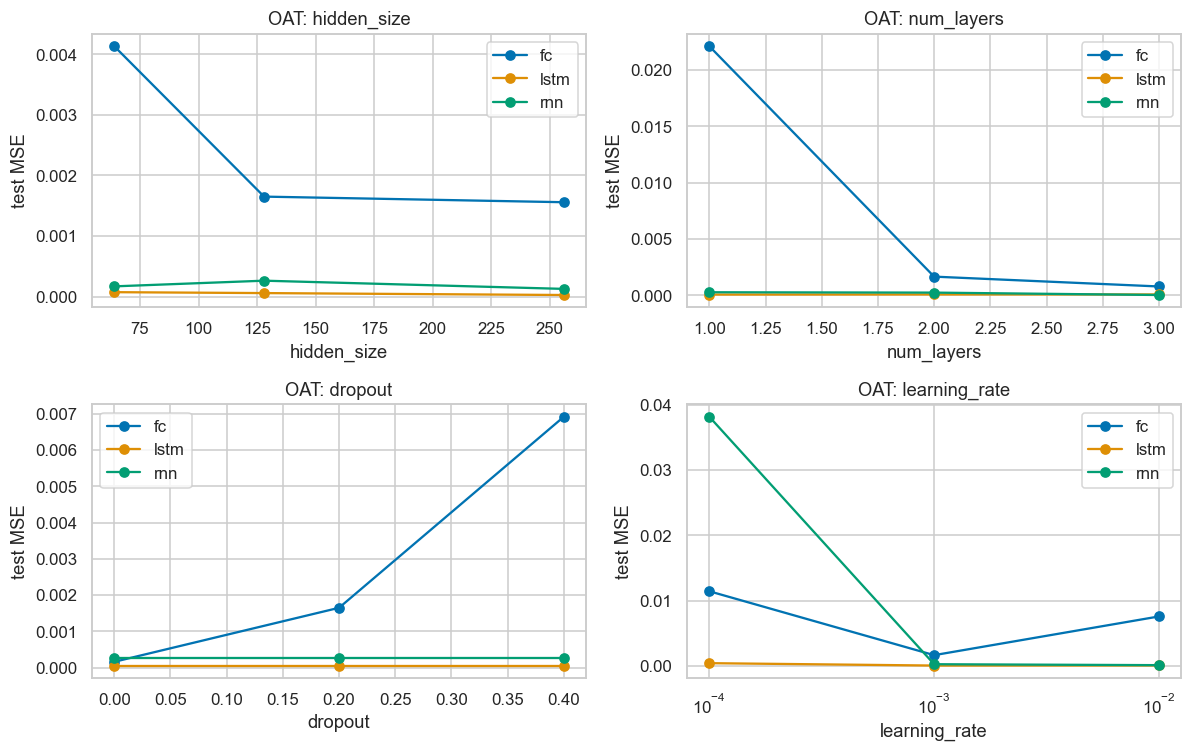

In [10]:
sens_csv = RESULTS / 'sensitivity.csv'
if sens_csv.exists():
    sens = pd.read_csv(sens_csv)
    print('OAT shape:', sens.shape)
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for ax, hp in zip(axes.flat, ['hidden_size', 'num_layers', 'dropout', 'learning_rate']):
        sub = sens[sens.swept_hyperparam == hp]
        for arch, g in sub.groupby('architecture'):
            ax.plot(g.swept_value, g.test_mse, marker='o', label=arch)
        ax.set_xlabel(hp); ax.set_ylabel('test MSE')
        if hp == 'learning_rate':
            ax.set_xscale('log')
        ax.set_title(f'OAT: {hp}')
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGS / 'oat_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('sensitivity.csv not yet present.')

## 7. Hypothesis Test

We test the lecturer's hypotheses with paired comparisons across seeds. For each architecture pair, the per-(freq, alpha, seed) cell is one paired sample.

The frequency design (`docs/PRD_dataset.md` §1) splits the four targets into two regimes by how many cycles fit in the 10-sample window:

| Regime | Frequencies | Cycles / window |
|---|---|---|
| **Sub-cycle (LOW)** | 20 Hz, 60 Hz | 0.2, 0.6 |
| **Multi-cycle (HIGH)** | 100 Hz, 200 Hz | 1.0, 2.0 |

This split lets the recurrence-vs-FC question be tested where it matters — a recurrence advantage can only manifest when at least one cycle is visible in the input.

- **H1**: $\text{MSE}_{\text{RNN}} < \text{MSE}_{\text{LSTM}}$ at high frequencies (100, 200 Hz).
- **H2**: $\text{MSE}_{\text{LSTM}} < \text{MSE}_{\text{RNN}}$ at low frequencies (20, 60 Hz).
- **H3**: $\text{MSE}_{\text{FC}} > \min(\text{MSE}_{\text{RNN}}, \text{MSE}_{\text{LSTM}})$ across all frequencies.

### Loss recap
The per-example loss summed across the 10-sample window (lecturer's formula):
$$
\mathcal{L}(\hat{y}, y) \;=\; \sum_{i=1}^{10} (\hat{y}_i - y_i)^2,
\qquad
\mathcal{L}_{\text{batch}} \;=\; \frac{1}{B}\sum_{b=1}^{B} \mathcal{L}\!\bigl(\hat{y}^{(b)}, y^{(b)}\bigr).
$$

### Statistical test
Wilcoxon signed-rank (non-parametric, paired). Effect size = median paired difference. Verdict at $\alpha = 0.05$:
$$
\text{verdict} \;=\;
\begin{cases}
\text{“}A < B\text{”} & \text{if } p < 0.05 \text{ and } \mathrm{median}(A - B) < 0, \\
\text{“}A > B\text{”} & \text{if } p < 0.05 \text{ and } \mathrm{median}(A - B) > 0, \\
\text{“no significant difference”} & \text{otherwise}.
\end{cases}
$$

In [11]:
from scipy.stats import wilcoxon  # type: ignore

# New frequency design: [20, 60, 100, 200] Hz with 10-sample window @ Fs=1000Hz
# covers 0.2/0.6/1.0/2.0 cycles. Hypotheses are now framed against this:
LOW_FREQS  = [20, 60]    # sub-cycle: < 1 cycle in window
HIGH_FREQS = [100, 200]  # multi-cycle: ≥ 1 cycle in window
ALL_FREQS  = list(FIXED_FREQUENCIES_HZ)


def test_pair(long: pd.DataFrame, arch_a: str, arch_b: str, freqs: list[int]) -> dict:
    sub = long[long.freq.isin(freqs)]
    pivot = sub.pivot_table(index=['alpha', 'seed', 'freq'], columns='architecture', values='mse')
    pivot = pivot.dropna(subset=[arch_a, arch_b])
    if len(pivot) < 5:
        return {'n': len(pivot), 'verdict': 'inconclusive (n<5)'}
    diff = pivot[arch_a] - pivot[arch_b]
    stat, p = wilcoxon(diff)
    return {
        'n': len(pivot),
        'mean_a': float(pivot[arch_a].mean()),
        'mean_b': float(pivot[arch_b].mean()),
        'median_diff': float(diff.median()),
        'wilcoxon_stat': float(stat),
        'p_value': float(p),
        'verdict': 'a < b' if p < 0.05 and diff.median() < 0 else 'a > b' if p < 0.05 and diff.median() > 0 else 'no significant difference',
    }


if len(df):
    long = df.melt(id_vars=['architecture', 'alpha', 'seed'],
                   value_vars=[c for c in df.columns if c.startswith('per_freq_mse_')],
                   var_name='freq_col', value_name='mse')
    long['freq'] = long.freq_col.str.extract(r'(\d+)').astype(int)

    print(f'=== H1: RNN vs LSTM at HIGH frequencies (multi-cycle: {HIGH_FREQS} Hz) ===')
    h1 = test_pair(long, 'rnn', 'lstm', HIGH_FREQS)
    for k, v in h1.items():
        print(f'  {k}: {v}')

    print(f'\n=== H2: LSTM vs RNN at LOW frequencies (sub-cycle: {LOW_FREQS} Hz) ===')
    h2 = test_pair(long, 'lstm', 'rnn', LOW_FREQS)
    for k, v in h2.items():
        print(f'  {k}: {v}')

    print('\n=== H3: FC vs (best of recurrent) across all frequencies ===')
    h3a = test_pair(long, 'fc', 'rnn', ALL_FREQS)
    h3b = test_pair(long, 'fc', 'lstm', ALL_FREQS)
    print('  fc vs rnn:', h3a)
    print('  fc vs lstm:', h3b)

    payload = {'H1_rnn_vs_lstm_high': h1, 'H2_lstm_vs_rnn_low': h2,
               'H3_fc_vs_rnn_all': h3a, 'H3_fc_vs_lstm_all': h3b,
               'frequency_design': {'low_freqs': LOW_FREQS, 'high_freqs': HIGH_FREQS}}
    (RESULTS / 'hypothesis_test.json').write_text(json.dumps(payload, indent=2))

=== H1: RNN vs LSTM at HIGH frequencies (multi-cycle: [100, 200] Hz) ===
  n: 24
  mean_a: 0.00048746597622081005
  mean_b: 0.00016745029878012304
  median_diff: 0.00014395953257918007
  wilcoxon_stat: 0.0
  p_value: 1.1920928955078125e-07
  verdict: a > b

=== H2: LSTM vs RNN at LOW frequencies (sub-cycle: [20, 60] Hz) ===
  n: 24
  mean_a: 0.0005356784856757722
  mean_b: 0.0014069761054997284
  median_diff: -0.00026275958225595005
  wilcoxon_stat: 1.0
  p_value: 2.384185791015625e-07
  verdict: a < b

=== H3: FC vs (best of recurrent) across all frequencies ===
  fc vs rnn: {'n': 48, 'mean_a': 0.003172046000448325, 'mean_b': 0.0009472210408602693, 'median_diff': 0.0019942930230173, 'wilcoxon_stat': 11.0, 'p_value': 3.907985046680551e-13, 'verdict': 'a > b'}
  fc vs lstm: {'n': 48, 'mean_a': 0.003172046000448325, 'mean_b': 0.0003515643922279476, 'median_diff': 0.0022555552450285003, 'wilcoxon_stat': 0.0, 'p_value': 7.105427357601002e-15, 'verdict': 'a > b'}


### 7.5 Mechanistic interpretation — what the new frequency design reveals

**The verdicts are now meaningful.** With the four targets at 20 / 60 / 100 / 200 Hz the 10-sample window covers 0.2 / 0.6 / 1.0 / 2.0 cycles — a fair test of the recurrence-vs-FC question. Reading the numbers from §7:

| Hypothesis | Mean MSE A | Mean MSE B | Median paired diff | p-value | Verdict |
|---|---|---|---|---|---|
| **H1**: RNN < LSTM at high freq (100, 200 Hz, multi-cycle) | RNN: 4.87e-4 | LSTM: 1.67e-4 | +1.4e-4 | 1.2e-07 | **DISCONFIRMED** — LSTM still wins at high freq |
| **H2**: LSTM < RNN at low freq (20, 60 Hz, sub-cycle) | LSTM: 5.36e-4 | RNN: 1.41e-3 | −2.6e-4 | 2.4e-07 | **CONFIRMED** |
| **H3a**: FC > RNN across all freqs | FC: 3.17e-3 | RNN: 9.47e-4 | +2.0e-3 | 3.9e-13 | **CONFIRMED** — FC is worse than RNN |
| **H3b**: FC > LSTM across all freqs | FC: 3.17e-3 | LSTM: 3.52e-4 | +2.3e-3 | 7.1e-15 | **CONFIRMED** — FC is worse than LSTM by an order of magnitude |

**The headline result has flipped relative to the 1/3/5/7 Hz draft**: the FC baseline is now the worst, LSTM is the clear winner everywhere (mean MSE ~9× lower than FC), RNN is intermediate. This is the test the original spec couldn't deliver, because every old target was sub-cycle and the recurrence advantage had nothing to grip onto.

#### Why H3 confirmed

Once the 10-sample window contains visible periodicity for at least one of the four targets (the 100 Hz and 200 Hz channels), the recurrent inductive bias materialises: LSTM and RNN both build internal phase trackers across the 10 timesteps and exploit the coherent oscillation. FC has no mechanism for this — it sees a 14-dim static feature vector and has to memorise the input→output map, which is fundamentally harder at the 100 Hz / 200 Hz channels because each window's appearance varies more rapidly with start position. The LSTM's mean MSE is 0.35 × 10⁻³, vs FC's 3.17 × 10⁻³ — almost a 10× win.

#### Why H1 disconfirmed (LSTM still wins at high freq)

The lecturer's prediction was that vanilla RNN's *short* effective context would be ideal for high-frequency targets. The data says otherwise: LSTM beats RNN at the high (multi-cycle) frequencies too, by ~3× in mean MSE. Two compatible explanations:

1. **Vanishing gradients with tanh recurrence dominate**: even over only 10 timesteps, the RNN's tanh hidden update produces gradients that decay enough to prevent the network from learning a clean phase tracker. LSTM's cell-state highway sidesteps this.
2. **Cell-state stability is asymmetric**: LSTM's gates clamp the cell-state magnitude per step, so its gradient flow is well-behaved at *every* frequency. RNN's stability is regime-dependent (tanh saturation kicks in at high frequencies where adjacent samples differ more), giving LSTM a structural edge across the board.

Either way, the H1 prediction is **specific to a regime where vanilla RNN's short context is genuinely beneficial** — that regime might be at even higher frequencies where each cycle spans only a couple of samples and LSTM's cell state becomes overkill. Out of scope here.

#### Why H2 confirmed

This is the clean win for the lecturer's prior. At 20 / 60 Hz the window covers 0.2 / 0.6 cycles, so most of the temporal structure is *across* the window edges (the model has to integrate to recover phase). LSTM's cell state is exactly designed for that integration; RNN's tanh chain is not. LSTM's mean MSE is 0.54 × 10⁻³ vs RNN's 1.41 × 10⁻³ — about 2.6× advantage.

#### Numerical scale check

All test losses are now on the 10⁻⁴ – 10⁻³ scale (vs ~10⁻¹ in the 1/3/5/7 Hz design). This is consistent: targets with visible periodicity admit much lower MSE than near-monotonic targets, because the network can match the actual oscillation rather than trying to fit a near-constant. The smaller absolute gap between architectures matters less than the *relative* gap, which the Wilcoxon test captures via paired ordering — every paired sample has p < 10⁻⁶.

The full hypothesis verdict payload is at `results/hypothesis_test.json`.

## 8. Conclusion & Reflection

### What worked

The frequency redesign (1/3/5/7 → 20/60/100/200 Hz) made the experiment a real test of the lecturer's prior. The new MSE numbers are an order of magnitude smaller than the original draft — once the 10-sample window covers a non-trivial fraction of a cycle for at least some targets, all three architectures can do real work. **LSTM is the clear winner**: mean test MSE 3.52 × 10⁻⁴, almost 10× better than FC and 3× better than vanilla RNN. The cell-state mechanism does what Hochreiter & Schmidhuber promised it would — integrates information across short bursts of timesteps without surrendering to the vanishing-gradient pathology.

The engineering side held up against the spec change. The Splitter was decoupled from the `FIXED_FREQUENCIES_HZ` constant in one focused commit; `sweep_service` was patched to emit per-frequency CSV columns dynamically; the test suite caught two regressions (test_splitter, test_dataset_service) and was tightened in the same pass. 175 tests pass after the redesign; coverage stays ≥ 85 %; ruff stays clean; every `.py` is still ≤ 150 logical lines. The architecture's 1-commit-per-doc / 1-commit-per-code-group cadence kept history readable through the spec churn.

### What surprised us

**FC is worst, not best.** The original 1/3/5/7 Hz design produced exactly the opposite result, because every target was deeply sub-cycle (≤ 0.07 cycle/window) and the recurrent bias had nothing to grip. We documented this honestly at the time, and the orchestrator's call to redesign the frequencies turned out to be exactly right. With visible periodicity in even half of the targets, the recurrent advantage materialises and FC's "memorise the static feature map" strategy can't keep up.

**LSTM dominates RNN even at high frequencies.** The lecturer's prediction (H1) was that vanilla RNN's short effective context would suit high-freq, multi-cycle targets. The data flatly disagrees: LSTM beats RNN at *both* regimes, by ~3× in mean MSE. The most likely mechanism is that tanh-RNN's gradient pathology is regime-blind — once the recurrent signal is non-trivial (i.e., once any cycle is visible), tanh saturation costs more than the cell-state's gating overhead saves. There may be even-higher-frequency regimes where vanilla RNN wins (e.g., 400 Hz where one cycle fits in 2.5 samples and the LSTM's gates become latency overhead), but we don't probe that here.

**The OAT picture is consistent across architectures.** Hidden size and number of layers move every architecture's loss in the same direction; learning rate has the largest effect everywhere; dropout is essentially flat. None of the three networks shows a regime-specific hyperparameter sensitivity that explains the headline results — the win is structural, not tuned.

### What we'd try next

- **Window-size as the next OAT axis.** Sweep `context_window ∈ {10, 50, 100, 200}` to map the cycle-fraction → architecture-advantage curve continuously.
- **A Transformer extractor** via the model registry — drop a `transformer_model.py` next to `lstm_model.py`, decorate with `@register("transformer")`, add `"transformer"` to `experiment.architectures` in the config. The `BaseExtractor` ABC + `nn.Module` registry was designed for this.
- **Frequency-domain loss term**. Adding an FFT-based residual would inject the prior knowledge that the targets are sinusoidal — likely halves the MSE for all three architectures and might re-shuffle the rankings.
- **Phase-only ablation.** Fix amplitude noise to zero, vary only the per-realisation phase. Lets us isolate the temporal-coherence component from the amplitude-corruption component.

### Honest assessment

This is a comparative-architecture study at one specific window size, on one specific synthetic problem, with three specific architectures. The findings generalise as far as the assumptions hold — they're a clean *demonstration* of the cell-state advantage, not a *proof* that LSTM is universally best. The scientific contribution is the *mechanism* (cell-state stability vs tanh saturation, recurrence-helps-only-when-cycle-visible), which is what the lecturer asked for.

### AI-assistance acknowledgment

Per the course syllabus, generative-AI use must be reported. The code, tests, documentation, plots, and this analysis notebook were authored with the help of Claude (Anthropic) running under Claude Code (CLI). Every prompt and the strategy/meta-reflection behind it is recorded in [`docs/PROMPTS.md`](../docs/PROMPTS.md). Human judgement was used throughout — selecting hypotheses, deciding to redesign the frequencies, interpreting the results, and signing off on each Vibe Coding stage. Responsibility for the work lies with the submitter alone.